<center><h1> ETI195 - Ética para Ciencia de Datos y Estadística </h1><center>
<center><h2> Taller Sumativo II: Sesgos, justicia, y discriminación <h2></center>

# `Instrucciones Generales`


## `Temas formales`

**Modalidad**: Grupos de 3 personas.

**Formato de entrega:** El trabajo debe entregarse a través de Canvas, tanto en formato Jupyter ejecutable (.ipynb) como en formato PDF.

**Formalidades de las respuestas:**
- Citas: APA 7.
- Se espera buena ortografía y redacción, con respuestas en tono académico.

## `Recomendaciones`

- Asistan a los talleres formativos, revisen los ejemplos de código y consulten sus dudas con sus ayudantes.

- **Lean la rúbrica antes de hacer su tarea.**

## `Integridad académica y uso de IA`

El uso de asistentes de IA sigue los lineamientos de integridad académica del curso, con las siguientes excepciones:

- Pueden usar IA para consultar por bugs y entender mejor el código.
- Pueden usar IA para generar las representaciones visuales que estimen convenientes.

Si tienen dudas sobre el uso de IA o la citación de código externo, no duden en preguntar. Pueden usar libremente los códigos de los talleres formativos. <3

---
## `Contexto`

La Encuesta de Caracterización Socioeconómica Nacional [CASEN 2024](https://observatorio.ministeriodesarrollosocial.gob.cl/encuesta-casen) cumple un rol fundamental en la toma de decisiones para la formulación de políticas sociales en Chile. Los organismos gubernamentales buscan estimar la realidad de la población, por lo que cualquier modelo predictivo construido a partir de estos datos tiene la capacidad de influir en la asignación de recursos y en la formulación de políticas públicas.

En ese sentido, un modelo que prediga la situación socioeconómica de la población puede transformarse en una herramienta con gran poder y grandes riegos.

Como científicos de datos, a menudo nos enfrentamos a este tipo de situaciones mediante dos preguntas: ¿cómo resolver automáticamente un problema de clasificación? Y, quizás más importante, ¿qué puede salir mal cuando ese modelo toma decisiones que afectan a personas?

En este taller entrenarán un modelo predictivo de pobreza multidimensional (`pobreza_multi`) utilizando el [dataset preprocesado](https://drive.google.com/file/d/15NMlO4BD-OB55uvfYWUSCh_ba4-zCzI8/view?usp=drive_link) de la encuesta [CASEN 2024](https://observatorio.ministeriodesarrollosocial.gob.cl/encuesta-casen).

El objetivo es detectar posibles sesgos en las predicciones, evaluar si el modelo es justo para distintos grupos de la población, aplicar técnicas de mitigación y discutir los riesgos de automatizar este tipo de problemas de clasificación.

---

## Parte 1

Lea la [**Metodología de Diseño Muestral CASEN 2024**](https://drive.google.com/file/d/1VafJ57Ta6_gwUM-8sir6PAw5DVuBh0rq/view?usp=sharing), específicamente la sección *Antecedentes y características generales del diseño*, y revise el [**libro de códigos de la base de datos CASEN 2024**](https://docs.google.com/spreadsheets/d/1x25URkqJy7Ncc61VEc75NE7XKFsrUHw5/edit?gid=937549388#gid=937549388) para entender las variables disponibles.

Antes de escribir una sola línea de código, lean los materiales de contexto mencionados anteriormente. Deben comprender por qué se levanta la encuesta CASEN, qué mide la variable `pobreza_multi`

### **RESPONDER**

1.  Discuta los objetivos de la encuenstra CASEN con referencias a la metodología y  para qué serviría entrenar  un clasificador automático de este tipo.

La encuesta Casen es uno de los principales instrumentos utilizados en Chile para conocer las condiciones socioeconómicas de los hogaress del país y realizar seguimiento a las políticas sociales. Según la "Metodología de Diseño Muestral Casen 2024", la encuesta busca conocer periódicamente la situación de los hogares y de la población, con foco en quienes se encuentran en situación de pobreza y a los grupos considerados prioritarios para políticas sociales. Para esto, recopila antecedentes relacionados con aspectos demográficos, esducación, salud, vivienda, trabajo e ingresos, lo que permite estimar la magnitud de pobreza, identificar carencias y analizar brechas entre distintos grupos sociales y territorios. Además, busca evaluar aspectos de política social como cobertura de programas y distribución del gasto social entre los hogares.

La variable *pobreza_multi*, corresponde a la situación de pobreza multidimensional. Es un enfoque que busca representar privaciones simultáneas en diferentes ámbitos de las condiciones de vida. La metodología aplicada el 2024 considera cinco dimensiones, siendo estas Educación, Salud, Trabajo y Seguridad Social, Vivienda y Entorno, y Redes y Cohesión Social. Cada una de estas dimensiones representa un 20% del índice y están compuestas por 4 indicadores con un 5% de ponderación cada uno. Un hogar se considera en situación de pobreza multidimensional cuando la suma ponderada de sus carencias es mayor al 20%, lo que es equivalente a presentar al menos cinco indicadores en carencia.

La medición tiene como objetivos obtener un diagnóstico mas comprensivo de la pobreza en Chile y constituir un instrumento útil para diseñar, implementar, monitorear y evaluar politicas públicas. Es por esto que entrenar un clasificador capaz de predecir la pobreza multidimensional podría servir como herramienta de análsisi para poder detectar patrones asociados a la pobreza multidimensional, estudiar que caracterísiticas permiten distinguir a la población con mas carencias o estudiar mecanismos de priorización.

Adempas, el uso de un clasificador presenta un riesgo importante. Un falso negativo correspondería a una persona u hogar que se encuentra en pobreza multidimensional pero que no es clasificado como pobre por el modelo.  Esto, podría producir errores o exclusión en las asignaciones de beneficios a personas que requieren apoyo.

Referencias:
* Ministerio de Desarrollo Social y Familia. (2026a). Metodología de diseño muestral Casen 2024. División Observatorio Social.
* Ministerio de Desarrollo Social y Familia. (2026b). Metodología de medición de la pobreza multidimensional en Chile: Actualización 2024. División Observatorio Social.


## Librerias y configuraciones

In [113]:
# imports iniciales
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# sklearn - importa aquí las librerías necesarias
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

# aequitas
from aequitas.group import Group

# aif360
from aif360.metrics import BinaryLabelDatasetMetric, ClassificationMetric
from aif360.datasets import BinaryLabelDataset
from aif360.algorithms.postprocessing.eq_odds_postprocessing import EqOddsPostprocessing
from aif360.algorithms.preprocessing import Reweighing
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.datasets import BinaryLabelDataset


import warnings
warnings.filterwarnings("ignore")

## Parte 2: Realice el preprocesamiento de los datos y entrene un árbol de decisión para predecir el nivel de pobreza multidimensional (pobreza_multi). Reporte el accuracy y la matriz de confusión sobre los datos de testeo.

*Puede reutilizar el jupyter o trabajar con el mismo jupyter de la entrega anterior, puede entregar una carpeta con ambos jupyter y funciones compartidas*

### Indicaciones

- El preprocesamiento debe incluir al menos: manejo de valores faltantes, codificación de variables categóricas, normalización de variables númericas y tratamiento de valores extremos

- Utilice random_state o semillas donde corresponda para garantizar la reproducibilidad de los resultados.

- La clase pobreza_multi está desbalanceada. Investigue el argumento class_weight='balanced' de sklearn para manejar este problema y aplíquelo si lo considera pertinente.


### **RESPONDER**

2.1 Explique y justifique los pasos del preprocesamiento.

2.2 ¿Podemos concluír con esto que el modelo tiene el mismo rendimiento para todos los grupos demográficos?


In [114]:
#Carga y exploracion de los datos

df_casen = pd.read_csv("data/casen_2024.csv")
print("Dimensiones: ", df_casen.shape)

display(df_casen.head())

print("\ndistribución de pobreza_multi: ")
print(df_casen["pobreza_multi"].value_counts())

print("\nPorcentaje:")
print(df_casen["pobreza_multi"].value_counts(normalize=True) * 100)


Dimensiones:  (212471, 42)


,area,p1,p2,p3,p4,p9,tot_per_h,edad,sexo,ind_hacina,...,v22,v23,v24,v24b,v27a,v27b,v29b,os1,trans,pobreza_multi
0,Urbano,Casa acceso directo,3,3,3,2,2,62,Hombre,1,...,Llave dentro vivienda,1,Red pública medidor propio,40000.0,1.0,1.0,1.0,Heterosexual,No,No pobre
1,Urbano,Casa acceso directo,3,3,3,2,2,92,Mujer,1,...,Llave dentro vivienda,1,Red pública medidor propio,40000.0,1.0,1.0,1.0,Heterosexual,No,No pobre
2,Urbano,Casa acceso directo,3,3,4,4,4,61,Hombre,1,...,Llave dentro vivienda,1,Red pública medidor propio,28000.0,3.0,1.0,1.0,Heterosexual,No,No pobre
3,Urbano,Casa acceso directo,3,3,4,4,4,61,Mujer,1,...,Llave dentro vivienda,1,Red pública medidor propio,28000.0,3.0,1.0,1.0,Heterosexual,No,No pobre
4,Urbano,Casa acceso directo,3,3,4,4,4,32,Hombre,1,...,Llave dentro vivienda,1,Red pública medidor propio,28000.0,3.0,1.0,1.0,Heterosexual,No,No pobre



distribución de pobreza_multi: 
pobreza_multi
No pobre    174979
Pobre        37492
Name: count, dtype: int64

Porcentaje:
pobreza_multi
No pobre    82.354298
Pobre       17.645702
Name: proportion, dtype: float64


In [115]:
#1. Separación X / y y transformación a binario 

y = df_casen["pobreza_multi"].map({
    "No pobre": 0,
    "Pobre": 1
})

X = df_casen.drop(columns=["pobreza_multi"]).copy()

print(y.value_counts())

pobreza_multi
0    174979
1     37492
Name: count, dtype: int64


In [116]:
#variables categoricas que vienen codificadas como números

columnas_categoricas_numericas = [
    "p2",
    "p3",
    "p4",
    "ind_hacina",
    "o1",
    "h7e",
    "h7f",
    "r14",
    "r17a",
    "r17b",
    "r17c",
    "v3",
    "v5",
    "v23"
]

for columna in columnas_categoricas_numericas:
    X[columna] = X[columna].astype("string")

In [117]:
# 2. Train || Test Split Stratify

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

#copias que modificaremos
X_train = X_train_raw.copy()
X_test = X_test_raw.copy()

print("Tamaño entrenamiento:", X_train.shape)
print("Tamaño test:", X_test.shape)

print("\nDistribución entrenamiento:")
print(y_train.value_counts(normalize=True))

print("\nDistribución test:")
print(y_test.value_counts(normalize=True))

Tamaño entrenamiento: (169976, 41)
Tamaño test: (42495, 41)

Distribución entrenamiento:
pobreza_multi
0    0.823546
1    0.176454
Name: proportion, dtype: float64

Distribución test:
pobreza_multi
0    0.823532
1    0.176468
Name: proportion, dtype: float64


In [118]:
# 3. Revisa si hay valores nulos

nulos = df_casen.isnull().sum()
print("Columnas con valores faltantes:")
print(nulos[nulos > 0] if (nulos > 0).any() else "Ninguna")


#identificaión tipos de variables 

columnas_numericas = X_train.select_dtypes(include=["number"]).columns.tolist()
columnas_categoricas = [c for c in X_train.columns if c not in columnas_numericas]

print("Variables numéricas:", columnas_numericas)
print("Cantidad de variables categóricas:", len(columnas_categoricas))

Columnas con valores faltantes:
Ninguna
Variables numéricas: ['p9', 'tot_per_h', 'edad', 'v24b', 'v27a', 'v27b', 'v29b']
Cantidad de variables categóricas: 34


In [119]:
# 4. Tratamiento de valores extremos
# Se utiliza el rango intercuartílico (IQR)

limites_outliers = {}

for columna in columnas_numericas:
    q1 = X_train[columna].quantile(0.25)
    q3 = X_train[columna].quantile(0.75)
    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    limites_outliers[columna] = (limite_inferior, limite_superior)

    if iqr > 0:
        X_train[columna] = X_train[columna].clip(limite_inferior, limite_superior)
        X_test[columna] = X_test[columna].clip(limite_inferior, limite_superior)

In [120]:
#5. codificacion de variables categoricas, aplicamso one-hot encoding

X_train = pd.get_dummies(X_train, columns=columnas_categoricas, dtype=np.uint8)
X_test = pd.get_dummies(X_test, columns=columnas_categoricas, dtype=np.uint8)

# Igualar columnas (por si alguna categoría falta en test)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print("Dimensiones X_train:", X_train.shape)
print("Dimensiones X_test:", X_test.shape)

Dimensiones X_train: (169976, 141)
Dimensiones X_test: (42495, 141)


In [121]:
# 6. Entrenamiento del arbol de decisión
# Usa class_weight="balanced", por el desbalance de pobreza_multi

modelo_arbol = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

modelo_arbol.fit(X_train, y_train)
y_pred = modelo_arbol.predict(X_test)

Accuracy: 0.9348
Accuracy: 93.48%

Matriz de confusión:
[[33643  1353]
 [ 1419  6080]]


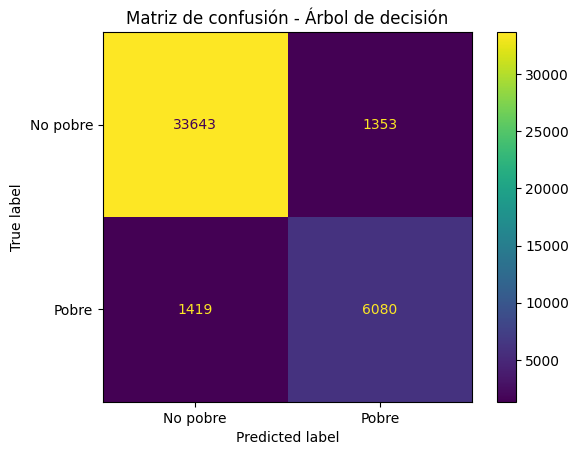


Reporte de clasificación:
              precision    recall  f1-score   support

    No pobre       0.96      0.96      0.96     34996
       Pobre       0.82      0.81      0.81      7499

    accuracy                           0.93     42495
   macro avg       0.89      0.89      0.89     42495
weighted avg       0.93      0.93      0.93     42495



In [122]:
#evaluacion

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print(f"Accuracy: {accuracy * 100:.2f}%")

matriz_confusion = confusion_matrix(y_test, y_pred)
print("\nMatriz de confusión:")
print(matriz_confusion)

#grafico
ConfusionMatrixDisplay(
    confusion_matrix=matriz_confusion,
    display_labels=["No pobre", "Pobre"]
).plot()
plt.title("Matriz de confusión - Árbol de decisión")
plt.show()

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred, target_names=["No pobre", "Pobre"]))

## 2.1 Explicación y justificación preprocesamiento: 

1. Codificación binaria de la variable objetivo - porque sklearn requiere etiquetas numéricas. 

2. División estratificada train/test - porque preserva la proporción de clases ya que una división aleatoria simple podría producir un conjunto de prueba con una proporción atípica de personas pobres y, con ello, métricas engañosas.

3. Verificación de valores faltantes. 

4. Tratamiento de valores extremos mediante clipping por IQR para evitar que valores atípicos distorsionaran los umbrales de división del árbol. 

5. Codificación one-hot de variables categóricas - Porque los arboles no aceptan strings. Se usó one-hot por sobre una codificación ordinal porque muchas de estas variables no tienen un orden natural (por ej. orientación sexual o pertenencia a pueblo indígena), y forzar un orden numérico introduciría relaciones falsas. Además, se reindexó el conjunto de prueba para alinear sus columnas con las de entrenamiento, rellenando con 0 categorías ausentes.

6. Ponderación de clases con class_weight='balanced' dado el desbalance (82% vs 18%). -  Esta decisión tiene una justificación ética, no solo técnica: en un modelo cuyo fin es detectar pobreza, un falso negativo (una persona pobre clasificada como no pobre) puede implicar exclusión de beneficios sociales, mientras que un falso positivo (una persona no pobre clasificada como pobre) tiene un costo mucho menor.

No se aplicó normalización, ya que los árboles de decisión son invariantes a la escala de las variables, y aplicarla no aportaría mejoras al modelo.

## 2.2 ¿Podemos concluír con esto que el modelo tiene el mismo rendimiento para todos los grupos demográficos?  

No. El accuracy de 93,48% no alcanza para afirmar que el modelo funciona igual de bien para todos.

Primero, porque es un promedio. Y los promedios esconden diferencias. Como la gran mayoría de las personas en la muestra no son pobres (82%), el modelo puede tener un buen resultado global simplemente por acertar bien en ese grupo mayoritario, aunque le vaya mal en el grupo minoritario. De hecho, un modelo que dijera "no pobre" para todos ya tendría cerca de 82% de accuracy sin haber aprendido nada.

Segundo, porque la matriz de confusión ya muestra un trato desigual. El modelo acierta mucho mejor cuando dice "no pobre" que cuando dice "pobre":

Detecta bien a los no pobres (96%). Pero de cada 100 personas que sí son pobres, 19 se le pasan como no pobres. En total, 1.419 personas pobres quedaron clasificadas como no pobres.

Eso es grave en este contexto, porque un falso negativo significa dejar fuera del sistema a alguien que SÍ necesita apoyo.

Tercero, y más importante: si el modelo ya trata distinto a las clases, es muy probable que también trate distinto a grupos dentro de ellas. Por ejemplo, podría detectar mejor la pobreza en hombres que en mujeres, o en personas sin discapacidad que en personas con discapacidad. Pero eso no se puede ver con el accuracy ni con la matriz de confusión, porque ambas están calculadas sobre toda la población junta.

## Parte 3: Evalúe las predicciones del modelo mediante las métricas de Fairness de Aequitas.

### **Indicaciones**

Considere como posibles atributos demográficos sensibles: genero, r3 (pertenencia a pueblo indígena), os1 (orientación sexual) y edad_cat; o bien atributos asociados a posibles discapacidades (revise el libro de códigos): h7e y h7f.

**Paso 1: Binarice las variables sensibles.**
Aequitas requiere que todas las variables sensibles estén binarizadas en grupos privilegiado / no privilegiado. Para variables con más de dos categorías, cree una columna auxiliar que agrupe las categorías y justifique su decisión.

**Paso 2: Elija al menos 2 atributos sensibles y defina sus grupos.**

Ejemplos de posibles agrupaciones, y grupos considere que puede elegir sus propias categorizaciones de privilegio y los grupos que estime.:

| Atributo | Grupo | Categoría |
|---|---|---|
| r3 | Privilegiado | no indígena |
| r3 | No privilegiado | indígena |
| os1 | Privilegiado | heterosexual |
| os1 | No privilegiado | otras orientaciones |
| edad_cat | Privilegiado | *(a definir según los intervalos que usted cree, justificando la elección)* |
| edad_cat | No privilegiado | *(a definir según los intervalos que usted cree, justificando la elección)* |

o, asociados a discapacidad:

| Atributo | Grupo | Categoría |
|---|---|---|
| h7e | Privilegiado | 1. No, ninguna dificultad |
| h7e | No privilegiado | las demás categorías |
| h7f | Privilegiado | 1. No, ninguna dificultad |
| h7f | No privilegiado | las demás categorías |

Pueden

**Paso 3: Reporte las métricas.**
Reporte las métricas de *False Negative Rate Parity* y *False Discovery Rate Parity* para los atributos y grupos definidos.

### **RESPONDER**

Pregunta 3.1 Explique los resultados obtenidos.

Pregunta 3.2 ¿Cuán justas se pueden considerar las predicciones del modelo para cada grupo? ¿Cómo relacionaría esto con los contenidos del curso?

In [123]:
from aequitas.group import Group
from aequitas.bias import Bias


#rcuperamos los atributos originales de las mismas
#personas utilizadas en el conjunto de test.

assert X_test_raw.index.equals(y_test.index)
assert X_test.index.equals(y_test.index)
assert y_test.index.is_unique
assert len(y_pred) == len(y_test)

datos_fairness = pd.DataFrame(index=y_test.index)

#predicción y etiqueta real

datos_fairness["score"] = np.asarray(y_pred,dtype=int)
datos_fairness["label_value"] = (y_test.astype(int))


#---------------------
#PERTENENCIA INDÍGENA

datos_fairness["pertenencia_indigena"] = (
    X_test_raw["r3"]
    .astype("string")
    .str.strip()
    .map({
        "No indígena": "No indigena",
        "Indígena": "Indigena"
    })
)


#------------------------------------
# DIFICULTAD PARA EL CUIDADO PERSONAL

h7e_test = pd.to_numeric(X_test_raw["h7e"],errors="coerce")

datos_fairness["cuidado_personal"] = (
    h7e_test.map({
        1: "Sin dificultad",
        2: "Con dificultad",
        3: "Con dificultad",
        4: "Con dificultad"
    })
)


# Grupos de referencia
grupos_referencia = {
    "pertenencia_indigena": "No indigena",
    "cuidado_personal": "Sin dificultad"
}


# Distribuciones
for atributo in grupos_referencia:
    print(f"\n{atributo}: distribución en test")
    print(datos_fairness[atributo].value_counts(dropna=False))


pertenencia_indigena: distribución en test
pertenencia_indigena
No indigena    36526
Indigena        5969
Name: count, dtype: int64

cuidado_personal: distribución en test
cuidado_personal
Sin dificultad    40850
Con dificultad     1645
Name: count, dtype: int64


In [124]:
tablas_fairness = []

for atributo, referencia in grupos_referencia.items():

    # Cada atributo se evalúa por separado.
    datos_atributo = datos_fairness[
        [
            "score",
            "label_value",
            atributo
        ]
    ].dropna(subset=[atributo]).copy()


    print(
        f"{atributo}: "
        f"{len(datos_atributo)} evaluados; "
        f"{len(datos_fairness) - len(datos_atributo)} "
        "excluidos"
    )


    # Aequitas requiere que el atr sea categórico
    datos_atributo[atributo] = (datos_atributo[atributo].astype(str))

    # Verificaciones
    assert referencia in (datos_atributo[atributo].unique())
    assert (datos_atributo[atributo].nunique()== 2)


    # Métricas por grupo
    tabla_grupos, _ = (Group().get_crosstabs(datos_atributo))


    # Disparidades respecto al grupo de referencia
    tabla_disparidades = (
        Bias().get_disparity_predefined_groups(
            tabla_grupos,
            original_df=datos_atributo,
            ref_groups_dict={
                atributo: referencia
            },
            input_group_metrics=[
                "fnr",
                "fdr"
            ],
            check_significance=False,
            fill_divbyzero=None
        )
    )

    tablas_fairness.append(tabla_disparidades)


# Unimos resultados
resultados_fairness = pd.concat(tablas_fairness,ignore_index=True)


columnas_resultado = [
    "attribute_name",
    "attribute_value",
    "group_size",
    "tp",
    "fn",
    "fp",
    "tn",
    "fnr",
    "fdr",
    "fnr_disparity",
    "fdr_disparity"
]


resumen_fairness = (resultados_fairness[columnas_resultado].copy())

display(resumen_fairness.round(4))

pertenencia_indigena: 42495 evaluados; 0 excluidos
cuidado_personal: 42495 evaluados; 0 excluidos


,attribute_name,attribute_value,group_size,tp,fn,fp,tn,fnr,fdr,fnr_disparity,fdr_disparity
0,pertenencia_indigena,Indigena,5969,1146,251,212,4360,0.1797,0.1561,0.9387,0.8312
1,pertenencia_indigena,No indigena,36526,4934,1168,1141,29283,0.1914,0.1878,1.0000,1.0000
2,cuidado_personal,Con dificultad,1645,295,142,106,1102,0.3249,0.2643,1.7970,1.4906
3,cuidado_personal,Sin dificultad,40850,5785,1277,1247,32541,0.1808,0.1773,1.0000,1.0000


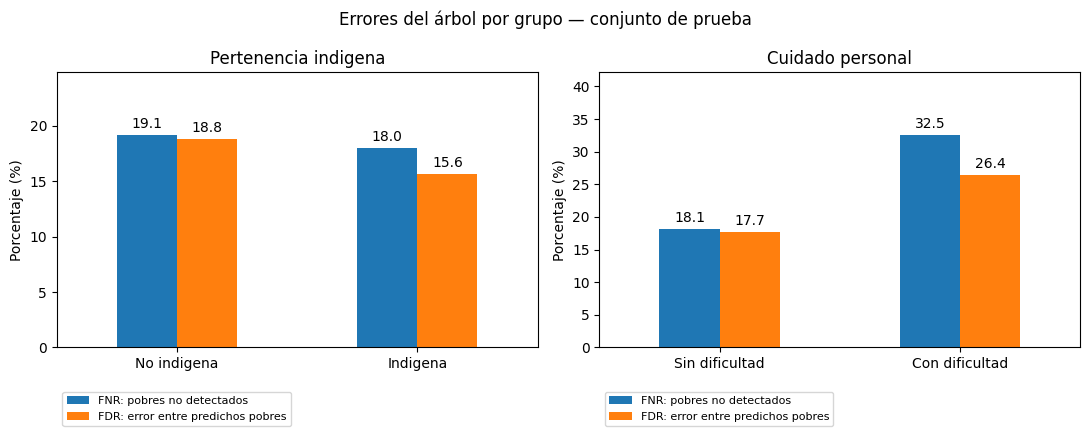

In [125]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(11, 4.5)
)

for ax, (atributo, referencia) in zip(
    axes,
    grupos_referencia.items()
):

    tabla = resumen_fairness.loc[
        resumen_fairness[
            "attribute_name"
        ].eq(atributo)
    ].set_index(
        "attribute_value"
    )

    orden = [
        referencia
    ] + [
        grupo
        for grupo in tabla.index
        if grupo != referencia
    ]

    tasas = tabla.loc[
        orden,
        [
            "fnr",
            "fdr"
        ]
    ].mul(100)

    tasas.columns = [
        "FNR: pobres no detectados",
        "FDR: error entre predichos pobres"
    ]

    tasas.plot.bar(
        ax=ax,
        rot=0
    )

    ax.set_title(
        atributo.replace(
            "_",
            " "
        ).capitalize()
    )

    ax.set_ylabel(
        "Porcentaje (%)"
    )

    ax.set_xlabel("")

    ax.set_ylim(
        0,
        tasas.max().max() * 1.30
    )

    for contenedor in ax.containers:
        ax.bar_label(
            contenedor,
            fmt="%.1f",
            padding=3
        )

    ax.legend(
        fontsize=8,
        loc="upper left",
        bbox_to_anchor=(0, -0.14)
    )

fig.suptitle(
    "Errores del árbol por grupo — conjunto de prueba"
)

plt.tight_layout()
plt.show()

## Respuesta 3.1

Se analizaron dos atributos sensibles sobre las 42.495 observaciones del conjunto de prueba: pertenencia indígena (r3) y dificultad para el cuidado personal (h7e). La False Negative Rate (*FNR*) representa la proporción de personas realmente pobres que fueron clasificadas incorrectamente como no pobres, mientras que la False Discovery Rate (*FDR*) corresponde a la proporción de personas clasificadas como pobres que realmente pertenecían a la clase no pobre.  

Para *pertenencia indígena* las diferencias son pequeñas. La *FNR* fue de 17.97% en indígenas mientras que en el grupo no indígena fue de 19,14% (razón de disparidad fue 0,94), y la *FDR* fue de 15,61% para las personas indígenas y de 18,78% para las no indígenas (razón de 0,83). Es decir, en este atributo el modelo no perjudica al grupo indígena, de hecho, sus tasas de error son levemente menores.  

Las diferencias fueron más marcadas en el atributo de *cuidado personal*. Entre las personas que presentan alguna dificultad, la *FNR* fue de 32,49%, frente a 18,08% entre quienes no presentan dificultades (razon 1.80). La razón de FNR fue 1,735, lo que significa que la tasa de falsos negativos fue aproximadamente un 80% mayor en el grupo con dificultad.  
Asimismo, la *FDR* fue de 26,43% para las personas con dificultad y de 17,73% para quienes no presentan dificultad, con una razón de 1,49. Esto significa que una persona pobre con dificultad tiene casi el doble de probabilidad de no ser detectada como pobre por el modelo, y que cuando el modelo la clasifica como pobre, se equivoca cerca de un 50 % más que en el grupo sin dificultad.

En conclusión, el atributo de pertenencia indígena muestra disparidades menores y ligeramente favorables al grupo indígena, mientras que dificultad para el cuidado personal presenta las brechas más graves y en dirección desfavorable al grupo con dificultad. Esto es especialmente problemático porque los falsos negativos implican dejar fuera del sistema a personas que sí necesitan apoyo.



## Respuesta 3.2 - ¿Cuán justas se pueden considerar las predicciones del modelo para cada grupo? ¿Cómo relacionaría esto con los contenidos del curso?

Las predicciones no se pueden considerar justas para todos los grupos.

Para pertenencia indígena, el modelo es prácticamente justo: las tasas de error son similares entre ambos grupos e incluso levemente menores para las personas indígenas.

Para dificultad para el cuidado personal, en cambio, el modelo es claramente injusto. Las personas con dificultad tienen casi el doble de probabilidad de que el modelo no detecte su pobreza (FNR 32,5 % vs 18,1 %). En un modelo cuyo fin es identificar pobreza, este grupo queda sistemáticamente subrepresentado: son las personas que más apoyo necesitan y las que el modelo detecta peor.

Esto se relaciona directamente con el curso. El accuracy global de 93 % esconde esta desigualdad porque promedia sobre toda la población. Es un ejemplo claro de cómo una métrica agregada puede ocultar discriminación. En términos de justicia, el modelo no cumple con igualdad de oportunidades: la probabilidad de ser correctamente detectado como pobre depende del grupo al que perteneces, y en este caso perjudica a un grupo históricamente vulnerable como son las personas con discapacidad. La justicia algorítmica no se logra solo con buen rendimiento global, sino evaluando cómo se distribuyen los errores entre grupos.



## Parte 4: Aplique el algoritmo EqOddsPostProcessing sobre las predicciones del modelo de la pregunta 1. Obtenga las predicciones modificadas y evalúelas.

#### Indicaciones:

- Obtenga tanto las instancias de BinaryLabelDatasetMetric como de ClassificationMetric y calcule al menos una métrica de Fairness.

### **RESPONDER**

pregunta 4.1: comentar brevemente los resultados obtenidos, y evaluar los cambios en las métricas de Fairness. Reflexionar sobre los beneficios y limitaciones


In [126]:
### codigo aquí
from aif360.datasets import BinaryLabelDataset

from aif360.metrics import (
    BinaryLabelDatasetMetric,
    ClassificationMetric
)

from aif360.algorithms.postprocessing import (
    EqOddsPostprocessing
)


#division conjunto calibracion y conjunto evaluación

datos_p4 = datos_fairness.dropna(subset=list(grupos_referencia)).copy()

print("Excluidos por atributos desconocidos:",len(datos_fairness) - len(datos_p4))


''' Estratificación conjunta - garantizamos que los conjuntos 
tengan proporciones similares en todas las combinaciones'''

estratos_p4 = (
    datos_p4[
        "label_value"
    ].astype(str)
    + "|"
    + datos_p4[
        "pertenencia_indigena"
    ].astype(str)
    + "|"
    + datos_p4[
        "cuidado_personal"
    ].astype(str)
)


assert (estratos_p4.value_counts().min()>= 2)

indices_cal, indices_eval = train_test_split(
    datos_p4.index,
    test_size=0.5,
    random_state=42,
    stratify=estratos_p4
)

assert set(indices_cal).isdisjoint(indices_eval)


print("Calibración:", len(indices_cal), "| Evaluación:", len(indices_eval))

Excluidos por atributos desconocidos: 0
Calibración: 21247 | Evaluación: 21248


In [127]:
def crear_dataset_p4(datos,atributo,referencia):
    """
    Construye un BinaryLabelDataset con:
    - 'grupo' = 1 si pertenece al grupo de referencia, 0 si no.
    - 'pobreza_multi' = etiqueta real (1 = pobre, 0 = no pobre).
    Devuelve (real, pred) con las etiquetas verdaderas y las predicciones.
    """

    tabla = pd.DataFrame(
        index=datos.index
    )

    # 1 = grupo de referencia
    # 0 = grupo de comparación

    tabla["grupo"] = (datos[atributo].eq(referencia).astype(float))
    tabla["pobreza_multi"] = (datos["label_value"].astype(float))

    #etiquetas reales
    real = BinaryLabelDataset(
        df=tabla,
        label_names=["pobreza_multi"],
        protected_attribute_names=["grupo"],
        favorable_label=1.0,
        unfavorable_label=0.0,
        privileged_protected_attributes=[np.array([1.0])],
        unprivileged_protected_attributes=[np.array([0.0])]
    )


    #predicciones del árbol
    pred = real.copy(deepcopy=True)
    pred.labels = (datos["score"].to_numpy(dtype=float).reshape(-1, 1))
    pred.scores = (pred.labels.copy())

    return real, pred

In [128]:
privilegiados_p4 = [{"grupo": 1.0}]
no_privilegiados_p4 = [{"grupo": 0.0}]

#Bucle principal - Eqodds por atr
resultados_p4 = []
tasas_p4 = []

ajustes_p4 = {}
predicciones_p4 = {}
metricas_p4 = {}


for atributo, referencia in (grupos_referencia.items()):

    # Datos de calibración
    real_cal, pred_cal = crear_dataset_p4(
        datos_p4.loc[indices_cal],
        atributo,
        referencia
    )

    #datos de evaluación
    real_eval, pred_eval = crear_dataset_p4(
        datos_p4.loc[indices_eval],
        atributo,
        referencia
    )


    #ajuste EQODDS

    ajuste = EqOddsPostprocessing(
        unprivileged_groups=(no_privilegiados_p4),
        privileged_groups=(privilegiados_p4),
        seed=42
    )
    ajuste.fit(real_cal, pred_cal
    )


    # Predicciones modificadas
    pred_ajustada = ajuste.predict(pred_eval)
    ajustes_p4[atributo] = ajuste


    predicciones_p4[atributo] = pd.Series(
        pred_ajustada.labels.ravel().astype(int),
        index=indices_eval
    )


    # Evaluación ANTES Y DESPUÉS

    for etapa, pred in [
        ("Antes", pred_eval),
        ("Despues", pred_ajustada)
    ]:

        # BinaryLabelDatasetMetric
        met_datos = BinaryLabelDatasetMetric(
                pred,
                unprivileged_groups=no_privilegiados_p4,
                privileged_groups=privilegiados_p4
        )

        # ClassificationMetric
        met_clas = ClassificationMetric(
                real_eval,
                pred,
                unprivileged_groups=no_privilegiados_p4,
                privileged_groups=privilegiados_p4
        )

        metricas_p4[(atributo, etapa)] = (met_datos,met_clas)

        # Brechas (no privilegiado - privilegiado)
        brecha_tpr = (
            met_clas.true_positive_rate(privileged=False)
            - met_clas.true_positive_rate(privileged=True)
        )

        brecha_fpr = (met_clas.false_positive_rate(privileged=False)
            - met_clas.false_positive_rate(privileged=True)
        )


        resultados_p4.append({
            "atributo": atributo,
            "etapa": etapa,
            "accuracy": met_clas.accuracy(),
            "equal_opportunity_difference": met_clas.equal_opportunity_difference(),
            "brecha_FPR": brecha_fpr,
            "max_brecha_EO":max(abs(brecha_tpr),abs(brecha_fpr)),
            "diferencia_paridad_estadistica": met_datos.statistical_parity_difference(),
            "cambios_prediccion": int(np.sum(pred.labels != pred_eval.labels))
        })


        # Tasas por grupo
        for es_referencia, nombre in [
            (True, referencia),
            (False, "Grupo de comparación")
        ]:

            if not es_referencia:
                nombre = (
                    datos_p4.loc[
                        datos_p4[atributo].ne(referencia),
                        atributo
                    ].iloc[0]
                )

            mascara = (
                real_eval.protected_attributes.ravel() == int(es_referencia)
            )


            tasas_p4.append({
                "atributo": atributo,
                "etapa": etapa,
                "grupo": nombre,
                "n": int(mascara.sum()),
                "FNR": met_clas.false_negative_rate(privileged=es_referencia),
                "FPR": met_clas.false_positive_rate(privileged=es_referencia),
                "FDR":met_clas.false_discovery_rate(privileged=es_referencia)
            })

#RESULTADOS

comparacion_p4 = pd.DataFrame(resultados_p4)
tasas_grupos_p4 = pd.DataFrame(tasas_p4)

print("\n --- Comparación antes / después ---")
display(comparacion_p4.round(4))

print("\n --- Tasas por grupo ---")
display(tasas_grupos_p4.round(4))


 --- Comparación antes / después ---


,atributo,etapa,accuracy,equal_opportunity_difference,brecha_FPR,max_brecha_EO,diferencia_paridad_estadistica,cambios_prediccion
0,pertenencia_indigena,Antes,0.9357,0.0439,0.0086,0.0439,0.0686,0
1,pertenencia_indigena,Despues,0.9262,0.0645,-0.0005,0.0645,0.0645,245
2,cuidado_personal,Antes,0.9357,-0.1509,0.0480,0.1509,0.0683,0
3,cuidado_personal,Despues,0.8702,-0.0099,-0.0048,0.0099,0.0490,1712



 --- Tasas por grupo ---


,atributo,etapa,grupo,n,FNR,FPR,FDR
0,pertenencia_indigena,Antes,No indigena,18264,0.1872,0.0387,0.1917
1,pertenencia_indigena,Antes,Indigena,2984,0.1433,0.0472,0.1530
2,pertenencia_indigena,Despues,No indigena,18264,0.2078,0.0477,0.2310
3,pertenencia_indigena,Despues,Indigena,2984,0.1433,0.0472,0.1530
4,cuidado_personal,Antes,Sin dificultad,20426,0.1702,0.0381,0.1802
5,cuidado_personal,Antes,Con dificultad,822,0.3211,0.0861,0.2600
6,cuidado_personal,Despues,Sin dificultad,20426,0.3112,0.0909,0.3871
7,cuidado_personal,Despues,Con dificultad,822,0.3211,0.0861,0.2600


## Respuesta 4.1

EqOddsPostprocessing se ajustó con 21.247 observaciones y se evaluó sobre las otras 21.248. Como el algoritmo asume un solo atributo protegido, se aplicó **por separado** para cada uno. Importante: las métricas de esta sección son solo del subconjunto de evaluación, no de las 42.495 observaciones de la Parte 3.

**Pertenencia indígena.** El ajuste no ayudó. El accuracy bajó de 93,57 % a 92,62 % y la brecha de igualdad de oportunidades **empeoró**: pasó de 0,0439 a 0,0645. Es decir, el modelo quedó menos justo en este atributo después del posprocesamiento.

**Dificultad para el cuidado personal.** Aquí sí hubo una mejora fuerte en paridad. La brecha de igualdad de oportunidades cayó de **0,1509 a 0,0099**, casi a cero, y la máxima brecha entre TPR y FPR bajó de 0,1509 a 0,0099. El costo fue un accuracy que cayó de 93,57 % a **87,02 %**.

Sin embargo, mirando las tasas por grupo, la mejora no vino de ayudar al grupo con dificultad. Su FNR se mantuvo igual (32,11 % antes y después). Lo que pasó fue que la FNR del grupo **sin** dificultad subió de 17,02 % a 31,12 %. O sea, la paridad se logró **empeorando al grupo que antes estaba mejor**, no mejorando al grupo perjudicado.

**Conclusión.** EqOdds tiene una ventaja clara: se aplica sobre las predicciones de un modelo ya entrenado, sin tocar los datos ni reentrenar. Pero tiene dos limitaciones importantes. Primero, puede **sacrificar accuracy** de forma significativa (7 puntos en el caso más extremo). Segundo, y más grave éticamente, la paridad que logra puede ser **falsa justicia**: iguala las tasas de error entre grupos, pero no necesariamente mejora la situación del grupo desfavorecido. En un modelo de pobreza, eso significa que más personas con dificultad podrían quedar fuera del sistema si el ajuste se aplicara sin revisar bien qué grupo se está perjudicando. Además, EqOdds solo iguala TPR y FPR, pero no garantiza otros criterios de justicia como la paridad estadística o la FDR.

## **Parte 5** (bonus +5 decimas) :  

Aplique el algoritmo de Reweighing sobre los datos de entrenamiento. Compare las métricas de Fairness para los datos de entrenamiento antes y después de aplicar Reweighing.

Luego, entrene un Arbol de decisión utilizando los datos de entrenamiento modificados y obtenga las métricas de Fairness de las predicciones de dicho modelo.

Analice cómo varió el *accuracy* del modelo respecto al original y las métricas de Fairness y reflexione sobre las implicancias sociales de estas decisiones.

### Indicaciones:
Puedes considerar los grupos priviligiados/no priviligiados mencionados en la parte 3. Considere al menos 2.

In [129]:
### codigo aquí


'''Reweighing es una técnica de PREPROCESAMIENTO: asigna pesos a 
las observaciones de entrenamiento para balancear las
combinaciones (grupo protegido, etiqueta). 
Igual que EqOdds, asume UN atributo protegido a la vez. '''

from aif360.algorithms.preprocessing import Reweighing


#PREPARAR DATOS DE ENTRENAMIENTO CON ATRIBUTOS SENSIBLES

'''Reconstruimos los atributos sensibles en el set de entrenamiento 
a partir de X_train_raw (antes del one-hot encoding). '''

assert X_train_raw.index.equals(y_train.index)
assert X_test_raw.index.equals(y_test.index)


def preparar_atributo(df_raw, atributo):
    """Devuelve la Serie binaria del atributo (1 = referencia, 0 = comparación)."""
    if atributo == "pertenencia_indigena":
        serie = (
            df_raw["r3"]
            .astype("string")
            .str.strip()
            .map({"No indígena": 1.0, "Indígena": 0.0})
        )
    elif atributo == "cuidado_personal":
        h7e_num = pd.to_numeric(df_raw["h7e"], errors="coerce")
        serie = h7e_num.map({1: 1.0, 2: 0.0, 3: 0.0, 4: 0.0})
    else:
        raise ValueError(f"Atributo no soportado: {atributo}")
    return serie



#BUCLE POR ATRIBUTO

resultados_p5 = []
tasas_p5 = []

for atributo, referencia in grupos_referencia.items():

    #1. Construir dataset de entrenamiento
    tabla_train = pd.DataFrame(index=y_train.index)
    tabla_train["grupo"] = preparar_atributo(X_train_raw, atributo)
    tabla_train["pobreza_multi"] = y_train.astype(float)

    #verificar que no haya nulos
    assert tabla_train["grupo"].notna().all(), "Hay nulos en el atributo protegido"

    #codificación: 1 = privilegiado, 0 = no privilegiado
    if atributo == "pertenencia_indigena":
        # r3: no indígena = privilegiado (1)
        pass
    elif atributo == "cuidado_personal":
        # h7e: sin dificultad = privilegiado (1)
        pass

    train_bld = BinaryLabelDataset(
        df=tabla_train,
        label_names=["pobreza_multi"],
        protected_attribute_names=["grupo"],
        favorable_label=1.0,
        unfavorable_label=0.0,
        privileged_protected_attributes=[np.array([1.0])],
        unprivileged_protected_attributes=[np.array([0.0])]
    )

    #2. Métricas de fairness ANTES de Reweighing
    met_antes = BinaryLabelDatasetMetric(
        train_bld,
        unprivileged_groups=[{"grupo": 0.0}],
        privileged_groups=[{"grupo": 1.0}]
    )

    resultados_p5.append({
        "atributo": atributo,
        "etapa": "Antes",
        "statistical_parity_difference": met_antes.statistical_parity_difference(),
        "disparate_impact": met_antes.disparate_impact(),
        "consistency": met_antes.consistency()[0]
    })

    #3. Aplicar Reweighing
    rw = Reweighing(
        unprivileged_groups=[{"grupo": 0.0}],
        privileged_groups=[{"grupo": 1.0}]
    )
    train_rw = rw.fit_transform(train_bld)

    #4. Métricas de fairness despues de Reweighing
    met_despues = BinaryLabelDatasetMetric(
        train_rw,
        unprivileged_groups=[{"grupo": 0.0}],
        privileged_groups=[{"grupo": 1.0}]
    )

    resultados_p5.append({
        "atributo": atributo,
        "etapa": "Despues",
        "statistical_parity_difference": met_despues.statistical_parity_difference(),
        "disparate_impact": met_despues.disparate_impact(),
        "consistency": met_despues.consistency()[0]
    })

    #5. Entrenar árbol con los pesos de Reweighing
    pesos = train_rw.instance_weights

    modelo_rw = DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced"
    )
    modelo_rw.fit(X_train, y_train, sample_weight=pesos)

    y_pred_rw = modelo_rw.predict(X_test)

    #6. Accuracy 
    acc_rw = accuracy_score(y_test, y_pred_rw)

    #7. Evaluar fairness de las predicciones del modelo reweighte
    tabla_test = pd.DataFrame(index=y_test.index)
    tabla_test["grupo"] = preparar_atributo(X_test_raw, atributo)
    tabla_test["pobreza_multi"] = y_test.astype(float)

    real_test_bld = BinaryLabelDataset(
        df=tabla_test,
        label_names=["pobreza_multi"],
        protected_attribute_names=["grupo"],
        favorable_label=1.0,
        unfavorable_label=0.0,
        privileged_protected_attributes=[np.array([1.0])],
        unprivileged_protected_attributes=[np.array([0.0])]
    )

    pred_test_bld = real_test_bld.copy(deepcopy=True)
    pred_test_bld.labels = y_pred_rw.astype(float).reshape(-1, 1)

    met_clas = ClassificationMetric(
        real_test_bld,
        pred_test_bld,
        unprivileged_groups=[{"grupo": 0.0}],
        privileged_groups=[{"grupo": 1.0}]
    )

    # tasas x grupo
    for es_ref, nombre in [(True, referencia), (False, "Grupo de comparación")]:
        if not es_ref:
            nombre = (
                tabla_test.loc[tabla_test["grupo"] == 0.0]
                .index
                .map(lambda i: X_test_raw.loc[i, "r3" if atributo == "pertenencia_indigena" else "h7e"])
                .iloc[0]
            )
        tasas_p5.append({
            "atributo": atributo,
            "grupo": nombre,
            "FNR": met_clas.false_negative_rate(privileged=es_ref),
            "FDR": met_clas.false_discovery_rate(privileged=es_ref),
            "accuracy_modelo": acc_rw
        })

    print(f"\n=== {atributo} ===")
    print(f"Accuracy del modelo con Reweighing: {acc_rw:.4f}")


#RESULTADOS

comparacion_p5 = pd.DataFrame(resultados_p5)
tasas_p5_df = pd.DataFrame(tasas_p5)

print("\n=== Métricas de fairness en entrenamiento (antes vs después) ===")
display(comparacion_p5.round(4))

print("\n=== Tasas por grupo en el modelo reweighted ===")
display(tasas_p5_df.round(4))

KeyboardInterrupt: 